In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from nested_pandas import read_parquet
from scipy.stats import chi2

In [2]:
lc_ddf = read_parquet("outputs/lsst_snia_dp2_visitdetector_ddf_results.parquet")
lc_wfd = read_parquet("outputs/lsst_snia_dp2_visitdetector_wfd_results.parquet")
lc_all = read_parquet("outputs/lsst_snia_dp2_visitdetector_results.parquet")

In [3]:
salt_ddf = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_ddf_lcfit_results.csv")
salt_wfd = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_wfd_lcfit_results.csv")
salt_all = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_lcfit_results.csv")

In [4]:
salt_fitz_ddf = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_ddf_lcfit_results_fitz.csv")
salt_fitz_wfd = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_wfd_lcfit_results_fitz.csv")
salt_fitz_all = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_lcfit_results_fitz.csv")

In [5]:
lc_ddf_1p5err = read_parquet("outputs/lsst_snia_dp2_visitdetector_ddf_1.5err_results.parquet")
lc_wfd_1p5err = read_parquet("outputs/lsst_snia_dp2_visitdetector_wfd_1.5err_results.parquet")
# lc_all_1p5err = read_parquet("outputs/lsst_snia_dp2_visitdetector_1.5err_results.parquet")

In [6]:
salt_fitz_ddf_1p5err = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_ddf_1.5err_lcfit_results_fitz.csv")
salt_fitz_wfd_1p5err = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_wfd_1.5err_lcfit_results_fitz.csv")
# salt_fitz_all_1p5err = pd.read_csv("outputs/lsst_snia_dp2_visitdetector_1.5err_lcfit_results_fitz.csv")

In [7]:
def plot_skymap(ax, ra_deg, dec_deg, title):
    ra_wrapped = np.where(ra_deg > 180, ra_deg - 360, ra_deg)
    # Mirror RA so it increases right-to-left (standard sky-map convention); Mollweide axes
    # don't support invert_xaxis(), so negate the data and relabel the ticks instead.
    ax.scatter(-np.deg2rad(ra_wrapped), np.deg2rad(dec_deg), s=5, alpha=0.5)
    ax.set_title(title)
    ax.grid(True)
    ax.set_xticklabels([f"{-np.rad2deg(t):.0f}°" for t in ax.get_xticks()])

In [8]:
def filter_saltpar(result_df):
    saltparcuts = (result_df.x1 > -3) & (result_df.x1 < 3)
    saltparcuts &= (result_df.c > -0.3) & (result_df.c < 0.3)
    saltparcuts &= (result_df.success == True)
    saltparcuts &= (result_df.t0_err < 1)
    saltparcuts &= (result_df.x1_err < 1)
    saltparcuts &= (result_df.c_err < 0.1)
    p_value = 1 - chi2.cdf(result_df.chisq, df=result_df.ndof)
    saltparcuts &= p_value > 1e-7
    return saltparcuts

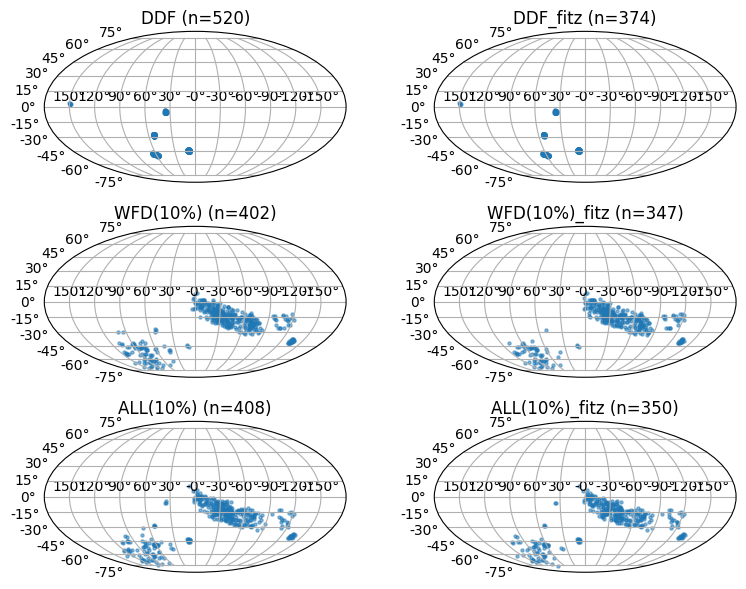

In [9]:
labels = ["DDF","WFD(10%)","ALL(10%)"]
fig, axes = plt.subplots(3, 2, figsize=(8, 6), subplot_kw={"projection": "mollweide"})

i=0
saltdf_list = [salt_ddf, salt_wfd, salt_all]
saltdf_fitz_list = [salt_fitz_ddf, salt_fitz_wfd, salt_fitz_all]
for label, df, in zip(labels,[lc_ddf, lc_wfd, lc_all]):
    saltpars = saltdf_list[i]
    saltpars["id"] = saltpars["id"].astype(int)
    df_plot = df[["id","ra","dec"]].merge(saltpars, on="id", how="inner")
    saltparcuts = filter_saltpar(df_plot)
    df_plot = df_plot[saltparcuts]
    plot_skymap(axes[i,0], df_plot["ra"], df_plot["dec"],
                f"{label} (n={len(df_plot):,})")
 
    saltpars = saltdf_fitz_list[i]
    saltpars["id"] = saltpars["id"].astype(int)
    df_plot = df[["id","ra","dec"]].merge(saltpars, on="id", how="inner")
    saltparcuts = filter_saltpar(df_plot)
    df_plot = df_plot[saltparcuts]
 
    plot_skymap(axes[i,1], df_plot["ra"], df_plot["dec"],
                f"{label}_fitz (n={len(df_plot):,})")
    i+=1
plt.tight_layout()
plt.show()

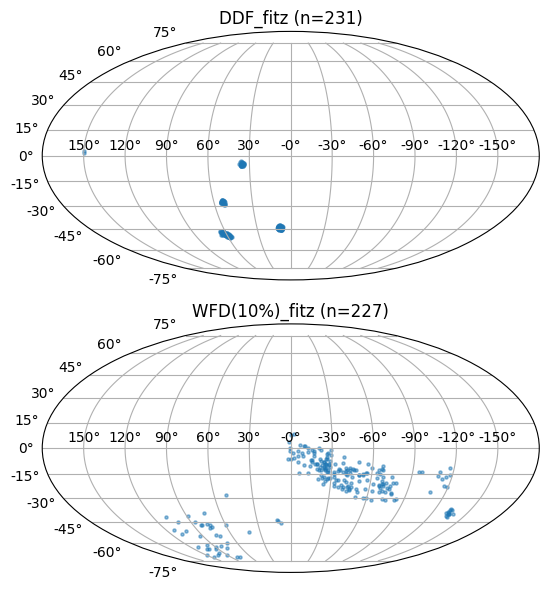

In [11]:
labels = ["DDF","WFD(10%)","ALL(10%)"]
fig, axes = plt.subplots(2, 1, figsize=(8, 6), subplot_kw={"projection": "mollweide"})

i=0
saltdf_fitz_list = [salt_fitz_ddf_1p5err, salt_fitz_wfd_1p5err]
for label, df, in zip(labels,[lc_ddf_1p5err, lc_wfd_1p5err]):
    saltpars = saltdf_fitz_list[i]
    saltpars["id"] = saltpars["id"].astype(int)
    df_plot = df[["id","ra","dec"]].merge(saltpars, on="id", how="inner")
    saltparcuts = filter_saltpar(df_plot)
    df_plot = df_plot[saltparcuts]
 
    plot_skymap(axes[i], df_plot["ra"], df_plot["dec"],
                f"{label}_fitz (n={len(df_plot):,})")
    i+=1
plt.tight_layout()
plt.show()